# 챗봇에서 도구 사용하기

In [2]:
from dotenv import load_dotenv
load_dotenv()

OPENAI_LLM_MODEL = 'gpt-4.1-mini'

## 도구 tool 정의

In [3]:
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results = 2)

# 도구 정상 동작 단독 확인
tavily_tool.invoke('LangGraph에서 노드는 무엇인가요?')

{'query': 'LangGraph에서 노드는 무엇인가요?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://tilnote.io/books/68156a4ebaa37b745385c23b/68156a79baa37b745385c298',
   'title': '3장: LangGraph의 핵심 구성요소 – 노드, 엣지, 상태 관리 - TILNOTE',
   'content': '3장: LangGraph의 핵심 구성요소 – 노드, 엣지, 상태 관리. ## LangGraph 핵심 컴포넌트 이해하기. LangGraph를 본격적으로 활용하려면 가장 먼저 세 가지 개념인 노드, 엣지, 그리고 상태 관리의 원리를 뚜렷하게 파악해야 한다. 이 장에서는 각각의 요소가 어떻게 맞물려 그래프 워크플로우를 구성하는지, 실제 개발 관점에서는 어떤 식으로 조합해야 하는지 자세히 다룬다. ## 노드: 독립 작업 단위의 정의. 노드는 LangGraph 워크플로우에서 하나하나의 작업 구간을 가리킨다. 각 노드는 입력으로 현재 상태 정보를 받고, 자신만의 작업 뒤에 업데이트된 상태를 돌려준다. ## 엣지: 흐름과 분기점 설계. 엣지는 단순하게 다음 작업 노드를 가리킬 수도 있고, 조건에 따라 서로 다른 경로를 지정할 수도 있다. 예를 들어 특정 분석 결과에 따라 다른 처리 로직으로 이동하게끔 조건부 분기를 만들 수 있다. 반복 구조나 순환 경로 또한 엣지 설계만으로 충분히 표현할 수 있다. LangGraph에서는 문맥과 작업 중간 결과 모두를 하나의 상태 객체에서 다룬다. 각 노드가 상태 객체에 자신의 결과나 작업 로그를 누적하는 식으로 설계하면, 전체 프로세스의 가시성과 확장성이 크게 높아진다. LangGraph의 진가는 상태, 노드, 엣지 세 요소의 치밀한 조합에서 드러난다.',
   'score': 0.9999846,
   'raw_content': None},
  {'ur

## LLM에 도구 바인딩하기

In [4]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model=OPENAI_LLM_MODEL)

tools = [tavily_tool]

# llm에게 사용 가능한 도구 목록을 알려준다.
llm_with_tools = llm.bind_tools(tools)

print(type(llm))
print(type(llm_with_tools))

<class 'langchain_openai.chat_models.base.ChatOpenAI'>
<class 'langchain_core.runnables.base.RunnableBinding'>


## 그래프 구성

### State 정의

In [5]:
from typing import Annotated,TypedDict
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage],add_messages]

c:\Users\Playdata\AppData\Local\miniforge3\envs\dl_nlp_env\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


### Chatbot Node 정의

In [6]:
def chatbot(state:State) -> State:
    response = llm_with_tools.invoke(state['messages'])
    return {'messages': [response]}

### Toolnode 정의

In [7]:
import json
from langchain_core.messages import ToolMessage

class SimpleToolNode:

    def __init__(self,tools):
        # 도구 이름으로 실제 도구 객체를 찾을 수 있도록 딕셔너리를 변환
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs: State) -> State:
        # LangGraph가 이 노드를 호출할 때 현재 state를 inputs로 전달한다.
        messages = inputs.get('messages',[])
        if not messages:
            raise ValueError('No messages found in inputs')
        
        ai_message = messages[-1]
        outputs = []
        for tool_call in ai_message.tool_calls:
            tool_name = tool_call['name']
            tool_args = tool_call['args']
            # 모델이 요청한 이름의 도구를 찾아 실행한다.
            tool_result = self.tools_by_name[tool_name].invoke(tool_args)
            # 도구 실행 결과는 ToolMessages로 감싸서 messages에 추가해야 한다.
            tool_message = ToolMessage(
                content=json.dumps(tool_result,ensure_ascii=False),
                name = tool_name,
                tool_call_id = tool_call['id']
            )
            outputs.append(tool_message)
        return {'messages':outputs}
        
simple_tool_node = SimpleToolNode(tools)

### 조건부 Edge 정의

In [8]:
from langgraph.graph import END

def route_tools(state:State):
    messages = state.get('messages',[])
    if not messages:
        raise ValueError('no messagesd found in input state')
    
    ai_message = messages[-1]

    # tool_calls가 있으면  tools 노드로 이동한다.
    has_tool_calls = bool(getattr(ai_message,'tool_calls',None))
    print(f'lasdd message has no calls? = {has_tool_calls}' )

    if has_tool_calls:
        return 'tools'
    
    return END

### 노드와 엣지 연결 후 컴파일

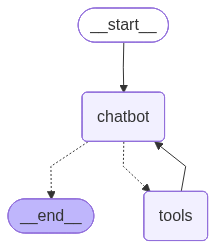

In [9]:
from langgraph.graph import START, StateGraph

workflow = StateGraph(State)

# 각 노드를 그래프에 등록한다.
workflow.add_node('chatbot',chatbot)
workflow.add_node('tools',simple_tool_node)

# 그래프 시작 지검은 chatbot 노드이다.
workflow.add_edge(START,'chatbot')

# 도구 실행 결괄를 LLM이 다시 읽고 최종 답변을 만들 수 있도록 catbot을 돌린다.
workflow.add_edge('tools','chatbot')

# chatbot의 결과에 tool_calls가 있으면 tools로 없으면 END로 이동한다.
workflow.add_conditional_edges(
    'chatbot',
    route_tools,
    {'tools':'tools',END:END}
)

graph = workflow.compile()
graph

## 그래프 실행

In [10]:
from langchain_core.messages import HumanMessage

# 검색 도구를 사용할 가능성이 높은 질문
user_input = '오늘 기준 LangGraph에서 ToolNode가 어떤 역할을 하는지 검색해서 설명해줘'
initial_state = {'messages' : [HumanMessage(content=user_input)]}

final_state = graph.invoke(initial_state)
final_state

lasdd message has no calls? = True
lasdd message has no calls? = False


{'messages': [HumanMessage(content='오늘 기준 LangGraph에서 ToolNode가 어떤 역할을 하는지 검색해서 설명해줘', additional_kwargs={}, response_metadata={}, id='c1dfc8ab-6b48-47eb-929d-212caabff83a'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 1205, 'total_tokens': 1235, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1152}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_ba030934dd', 'id': 'chatcmpl-DggkcKuYX9Pi1QWHrn6lofzQnEP41', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e38a0-2921-7542-9b2e-d17b4ac9680f-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'LangGraph ToolNode 역할', 'time_range': 'year', 'search_depth': 'advanced'}, 'id': 'call_bnQa8lRlLoL822imrMQh

In [11]:
from IPython.display import Markdown
# 최종 답변만 확인
Markdown(final_state['messages'][-1].content)

LangGraph의 ToolNode는 마지막 AIMessage에서 요청된 도구들을 실행하는 역할을 합니다. ToolNode는 StateGraph의 "messages" 키와 함께 사용되거나 MessageGraph에서 사용될 수 있습니다. 만약 여러 도구 호출이 요청되면, 이들은 병렬로 실행됩니다. 실행 결과로는 각 도구 호출에 대한 ToolMessages 리스트가 반환됩니다.

간단히 말해, ToolNode는 AI 메시지로부터 도구 호출을 감지하여 해당 도구들을 실행하고, 그 결과를 처리하는 노드입니다.

In [14]:
## 도구 요청이 필요하지 않을 것 같은 일반 질문
user_input = '인공지능이 사람의 삷에 어떻게 변화시킬까?'
initial_state = {'messages':[HumanMessage(content=user_input)]}

final_state = graph.invoke(initial_state)
# 최종 답변 확인
Markdown(final_state['messages'][-1].content)

lasdd message has no calls? = False


인공지능(AI)은 사람의 삶에 다양한 방식으로 변화를 가져오고 있습니다. 주요 변화를 몇 가지로 정리하면 다음과 같습니다:

1. 업무 자동화와 생산성 향상: 반복적이고 단순한 업무를 AI가 자동화함으로써 사람들은 더 창의적이고 전략적인 일에 집중할 수 있게 됩니다. 예를 들어, 제조업, 물류, 금융업에서 AI가 데이터 분석, 품질 검사, 고객 응대 등을 처리합니다.

2. 개인 맞춤형 서비스: AI는 개인의 취향, 습관, 건강 상태 등을 분석하여 맞춤형 추천, 맞춤형 의료, 맞춤형 교육 등을 제공합니다. 이는 삶의 질을 높이고 효율성을 증가시키는 데 기여합니다.

3. 새로운 일자리와 직업 변화: AI 기술 발전으로 새로운 산업과 직업이 생겨나고, 기존 직업도 변화합니다. 일부 단순 작업은 줄어들지만, AI 시스템을 관리하고 운영하는 전문 인력 수요는 증가합니다.

4. 의사결정 지원: 복잡한 데이터 분석과 예측을 통해 경영, 정책, 개인 선택 등에서 더 나은 의사결정을 할 수 있도록 돕습니다.

5. 생활 편의성 증대: 스마트홈, 자율주행차, 개인 비서 AI 등으로 일상 생활이 더 편리하고 안전해집니다.

6. 사회적·윤리적 도전: AI 활용에 따른 개인정보 보호, 편향성 문제, 일자리 대체 문제 등 새로운 사회적 윤리적 쟁점이 등장하고 있습니다.

요약하면, 인공지능은 사람들의 삶을 더 편리하고 효율적으로 만들어 주는 동시에, 새로운 도전과 변화를 동반하는 중요한 기술이라고 할 수 있습니다. 필요하시면 특정 분야에서 AI가 어떻게 작용하는지 더 자세히 설명드릴 수도 있습니다.

## built-in ToolNode & tools_conditions 사용하기
- 'ToolNode' : 마지막 AImessage의 tool_calls를 실행하고 ToolMessages를 추가한다.
- 'tools_condition' : 마지막 AIMessage에 tool_calls가 있으면 tools 노드로, 없으면 END로 라우팅 한다.

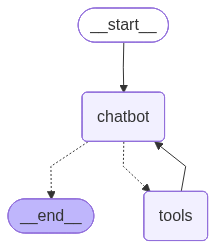

In [15]:
from langgraph.prebuilt import ToolNode, tools_condition

# LangGraph가 제공하는 공식 ToolNode를 사용한다.
tool_node = ToolNode(tools)

from langgraph.graph import START, StateGraph

workflow = StateGraph(State)

# 각 노드를 그래프에 등록한다.
workflow.add_node('chatbot',chatbot)
workflow.add_node('tools',tool_node)

# 그래프 시작 지검은 chatbot 노드이다.
workflow.add_edge(START,'chatbot')

# 도구 실행 결괄를 LLM이 다시 읽고 최종 답변을 만들 수 있도록 catbot을 돌린다.
workflow.add_edge('tools','chatbot')

# chatbot의 결과에 tool_calls가 있으면 tools로 없으면 END로 이동한다.
workflow.add_conditional_edges(
    'chatbot',
    tools_condition,
    {'tools':'tools',END:END}
)

prebuilt_graph = workflow.compile()
prebuilt_graph

In [16]:
from langchain_core.messages import HumanMessage

# 검색 도구를 사용할 가능성이 높은 질문
user_input = '오늘 기준 LangGraph에서 ToolNode가 어떤 역할을 하는지 검색해서 설명해줘'
initial_state = {'messages' : [HumanMessage(content=user_input)]}

final_state = prebuilt_graph.invoke(initial_state)
final_state

{'messages': [HumanMessage(content='오늘 기준 LangGraph에서 ToolNode가 어떤 역할을 하는지 검색해서 설명해줘', additional_kwargs={}, response_metadata={}, id='c33a1278-1ed1-424c-a19e-69a404af24b0'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 1205, 'total_tokens': 1230, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1152}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_ba030934dd', 'id': 'chatcmpl-Dggu8TSzIaEAiSfB1YuHN87ZlNoQB', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e38a9-2fe2-79c3-b3a0-7744e5bf4376-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'LangGraph ToolNode 역할', 'time_range': 'day'}, 'id': 'call_tk6RSmOIbEBsZpNoCFoBrhuF', 'type': 'tool_call'}],

In [19]:
## 도구 요청이 필요하지 않을 것 같은 일반 질문
user_input = '인공지능이 사람의 삷에 어떻게 변화시킬까?'
initial_state = {'messages':[HumanMessage(content=user_input)]}

final_state = prebuilt_graph.invoke(initial_state)
# 최종 답변 확인
final_state

{'messages': [HumanMessage(content='인공지능이 사람의 삷에 어떻게 변화시킬까?', additional_kwargs={}, response_metadata={}, id='bec1c993-5edb-4400-ac8c-206970f49b09'),
  AIMessage(content='인공지능(AI)은 사람의 삶에 다양한 방식으로 변화를 가져오고 있습니다. 주요 영향을 몇 가지로 정리해 보면 다음과 같습니다:\n\n1. 일자리와 노동시장 변화:\n   - 자동화와 로봇 기술로 반복적이고 단순한 업무가 대체되어 효율성이 높아지고, 사람이 더 창의적이고 복잡한 업무에 집중할 수 있는 기회를 제공합니다.\n   - 그러나 일부 직업은 사라질 위험이 있으며, 새로운 직업과 역할이 등장하는 등 노동시장의 구조가 변화합니다.\n\n2. 의료와 건강관리 혁신:\n   - AI는 진단, 치료 계획 수립, 환자 모니터링 등에 활용되어 의료 서비스의 정확성과 접근성을 높입니다.\n   - 맞춤형 치료와 예방의학이 진전되어 건강관리의 질이 향상됩니다.\n\n3. 교육과 학습의 개인화:\n   - 학습자 맞춤형 교육 콘텐츠와 방법이 개발되어 개인별 학습 속도와 스타일에 맞춘 교육이 가능해집니다.\n   - 온라인 교육과 AI 튜터가 보편화되어 더 많은 사람이 높은 질의 교육을 받을 수 있습니다.\n\n4. 일상생활의 편리함 증대:\n   - 음성인식, 스마트홈, 자율주행차 등 AI 기반 기술이 생활의 편리성과 안전성을 높입니다.\n   - 개인 비서 역할을 하는 AI가 일정 관리, 정보 검색 등 다양한 업무를 도와줍니다.\n\n5. 의사결정 지원과 문제 해결:\n   - 빅데이터와 AI 분석을 통해 복잡한 문제 해결과 전략 수립이 효율적으로 이루어집니다.\n   - 기업과 정부가 더 정확한 의사결정을 할 수 있게 됩니다.\n\n6. 사회적, 윤리적 문제:\n   - 프라이버시, 보안, 편향성 등 AI 사용에 따른 윤리적 문제와 규제 필요성이 대두되고 있습니다.\